# 03 - Train RT-DETR-L on DataPCB Final Clean 6-Class Dataset

This notebook is standardized from the previous working notebook `11_gk_rt_detr.ipynb`.

Key design choices copied from the previous working setup:

- use `RTDETR`, not `YOLO`
- use `rtdetr-l.pt`
- use `batch=32`
- use `device=[0, 1]`
- use `workers=8`
- use `deterministic=False`
- copy dataset from `/kaggle/input` to `/kaggle/working` before training
- train from a writable dataset folder so Ultralytics can create cache files

Dataset source expected:

```text
/kaggle/input/datasets/chungkein/pcb-merged/DataPCB_Final_Clean_6cls
```

Alternative source also supported:

```text
/kaggle/input/datasets/minhquan228/pcb-merged/DataPCB_Final_Clean_6cls
```

## 0. Install matching Ultralytics version

In [1]:
# Match the previous working notebook as closely as possible.
# Important: run this before importing ultralytics.
%pip -q install ultralytics==8.4.30

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 21.4 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


## 1. Imports and paths

In [2]:
from pathlib import Path
import shutil
import json
import yaml
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
import torch
from ultralytics import RTDETR

print("torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA device count:", torch.cuda.device_count())

for i in range(torch.cuda.device_count()):
    print(i, torch.cuda.get_device_name(i))

# Possible Kaggle dataset locations.
POSSIBLE_INPUT_ROOTS = [
    Path("/kaggle/input/datasets/chungkein/pcb-merged/DataPCB_Final_Clean_6cls"),
    Path("/kaggle/input/datasets/minhquan228/pcb-merged/DataPCB_Final_Clean_6cls"),
    Path("/kaggle/input/pcb-merged/DataPCB_Final_Clean_6cls"),
]

SOURCE_DATASET_ROOT = None
for p in POSSIBLE_INPUT_ROOTS:
    print("Checking:", p, "| exists:", p.exists())
    if p.exists():
        SOURCE_DATASET_ROOT = p
        break

assert SOURCE_DATASET_ROOT is not None, "Could not find DataPCB_Final_Clean_6cls in expected Kaggle input paths."

ROOT = Path("/kaggle/working")
DATA_DIR = ROOT / "DataPCB_Final_Clean_6cls"
DATA_YAML = DATA_DIR / "data.yaml"

PROJECT = "PCB_Baseline"
TRAIN_NAME = "rt_detr_l_final_clean_6cls_e50"
TEST_NAME = "rt_detr_l_final_clean_6cls_test_eval"
PRED_NAME = "rt_detr_l_final_clean_6cls_test_predictions"

TRAIN_DIR = ROOT / "runs" / "detect" / PROJECT / TRAIN_NAME
TEST_DIR = ROOT / "runs" / "detect" / PROJECT / TEST_NAME
PRED_DIR = ROOT / "runs" / "detect" / PROJECT / PRED_NAME

BEST_PT = TRAIN_DIR / "weights" / "best.pt"
LAST_PT = TRAIN_DIR / "weights" / "last.pt"
RESULTS_CSV = TRAIN_DIR / "results.csv"

REPORT_DIR = ROOT / "rt_detr_reports"
REPORT_DIR.mkdir(parents=True, exist_ok=True)

print("SOURCE_DATASET_ROOT:", SOURCE_DATASET_ROOT)
print("DATA_DIR:", DATA_DIR)
print("DATA_YAML:", DATA_YAML)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
torch: 2.10.0+cu128
CUDA available: True
CUDA device count: 2
0 Tesla T4
1 Tesla T4
Checking: /kaggle/input/datasets/chungkein/pcb-merged/DataPCB_Final_Clean_6cls | exists: True
SOURCE_DATASET_ROOT: /kaggle/input/datasets/chungkein/pcb-merged/DataPCB_Final_Clean_6cls
DATA_DIR: /kaggle/working/DataPCB_Final_Clean_6cls
DATA_YAML: /kaggle/working/DataPCB_Final_Clean_6cls/data.yaml


## 2. Copy dataset to `/kaggle/working`

In [3]:
# Copying to /kaggle/working mirrors the previous working notebook and avoids read-only cache warnings.
# It also allows Ultralytics to create labels.cache, which improves repeated dataloader startup.

if DATA_DIR.exists():
    print("Dataset already exists in /kaggle/working:", DATA_DIR)
else:
    print("Copying dataset to /kaggle/working...")
    shutil.copytree(SOURCE_DATASET_ROOT, DATA_DIR)
    print("Copied:", DATA_DIR)

for split in ["train", "valid", "test"]:
    img_dir = DATA_DIR / split / "images"
    lbl_dir = DATA_DIR / split / "labels"
    print(split, "| images:", img_dir.exists(), "| labels:", lbl_dir.exists())
    assert img_dir.exists(), f"Missing image dir: {img_dir}"
    assert lbl_dir.exists(), f"Missing label dir: {lbl_dir}"

Copying dataset to /kaggle/working...
Copied: /kaggle/working/DataPCB_Final_Clean_6cls
train | images: True | labels: True
valid | images: True | labels: True
test | images: True | labels: True


## 3. Rewrite `data.yaml` for the working dataset

In [4]:
CLASS_NAMES = [
    "missing_hole",
    "mouse_bite",
    "open_circuit",
    "short",
    "spur",
    "spurious_copper",
]

data_yaml = {
    "path": str(DATA_DIR),
    "train": "train/images",
    "val": "valid/images",
    "test": "test/images",
    "nc": len(CLASS_NAMES),
    "names": CLASS_NAMES,
}

with open(DATA_YAML, "w") as f:
    yaml.safe_dump(data_yaml, f, sort_keys=False)

print(DATA_YAML.read_text())

path: /kaggle/working/DataPCB_Final_Clean_6cls
train: train/images
val: valid/images
test: test/images
nc: 6
names:
- missing_hole
- mouse_bite
- open_circuit
- short
- spur
- spurious_copper



## 4. Quick dataset check

In [5]:
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff"}

def list_images(img_dir: Path):
    return sorted([p for p in img_dir.iterdir() if p.suffix.lower() in IMG_EXTS])

def read_yolo_label(label_path: Path):
    objects = []
    if not label_path.exists():
        return objects
    text = label_path.read_text().strip()
    if not text:
        return objects
    for line in text.splitlines():
        parts = line.split()
        if len(parts) != 5:
            continue
        cls_id = int(float(parts[0]))
        objects.append(cls_id)
    return objects

summary_rows = []
class_rows = []

for split in ["train", "valid", "test"]:
    img_dir = DATA_DIR / split / "images"
    lbl_dir = DATA_DIR / split / "labels"
    images = list_images(img_dir)

    c = Counter()
    total_boxes = 0

    for img in images:
        labels = read_yolo_label(lbl_dir / f"{img.stem}.txt")
        total_boxes += len(labels)
        for cls_id in labels:
            c[cls_id] += 1

    summary_rows.append({
        "split": split,
        "num_images": len(images),
        "total_boxes": total_boxes,
        "mean_boxes_per_image": total_boxes / max(1, len(images)),
    })

    for cls_id, cls_name in enumerate(CLASS_NAMES):
        class_rows.append({
            "split": split,
            "class_id": cls_id,
            "class_name": cls_name,
            "num_boxes": int(c.get(cls_id, 0)),
        })

summary_df = pd.DataFrame(summary_rows)
class_df = pd.DataFrame(class_rows)

display(summary_df)
display(class_df)

summary_df.to_csv(REPORT_DIR / "dataset_summary.csv", index=False)
class_df.to_csv(REPORT_DIR / "class_distribution.csv", index=False)

assert summary_df.loc[summary_df["split"] == "train", "num_images"].iloc[0] > 0
assert summary_df.loc[summary_df["split"] == "valid", "num_images"].iloc[0] > 0
assert summary_df.loc[summary_df["split"] == "test", "num_images"].iloc[0] > 0

,split,num_images,total_boxes,mean_boxes_per_image
0,train,6624,19176,2.894928
1,valid,937,2712,2.894344
2,test,1887,5352,2.836248


,split,class_id,class_name,num_boxes
0,train,0,missing_hole,3417
1,train,1,mouse_bite,3517
2,train,2,open_circuit,3007
3,train,3,short,2077
4,train,4,spur,4599
5,train,5,spurious_copper,2559
6,valid,0,missing_hole,478
7,valid,1,mouse_bite,460
8,valid,2,open_circuit,411
9,valid,3,short,307


## 5. Train RT-DETR-L

In [6]:
assert torch.cuda.device_count() >= 2, "This notebook expects Kaggle T4 x2 for the 11_gk-style config."

model = RTDETR("rtdetr-l.pt")

model.train(
    data=str(DATA_YAML),
    epochs=50,
    imgsz=640,
    batch=32,
    device=[0, 1],
    workers=8,
    amp=True,
    seed=42,
    deterministic=False,
    patience=10,
    project=PROJECT,
    name=TRAIN_NAME,
    exist_ok=True,
    val=True,
    plots=True,
    save=True,
    save_period=5
)

New https://pypi.org/project/ultralytics/8.4.53 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.30 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
                                                       CUDA:1 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/DataPCB_Final_Clean_6cls/data.yaml, degrees=0.0, deterministic=False, device=0,1, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, m

## 6. Evaluate on test set

In [7]:
eval_weight = BEST_PT if BEST_PT.exists() else LAST_PT
assert eval_weight.exists(), f"No trained weight found. Checked: {BEST_PT} and {LAST_PT}"

best_model = RTDETR(str(eval_weight))

test_metrics = best_model.val(
    data=str(DATA_YAML),
    split="test",
    imgsz=640,
    batch=32,
    device=[0, 1],
    project=PROJECT,
    name=TEST_NAME,
    exist_ok=True,
    plots=True,
    save_json=True
)

print(test_metrics)

Ultralytics 8.4.30 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
                                                       CUDA:1 (Tesla T4, 14913MiB)
rt-detr-l summary: 310 layers, 31,996,070 parameters, 0 gradients, 103.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 7.9±4.2 MB/s, size: 29.4 KB)
val: Scanning /kaggle/working/DataPCB_Final_Clean_6cls/test/labels... 1887 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1887/1887 878.5it/s 2.1s
val: New cache created: /kaggle/working/DataPCB_Final_Clean_6cls/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 59/59 1.4s/it 1:23
                   all       1887       5352      0.916      0.892      0.928      0.656
          missing_hole        541        986      0.919      0.972      0.981      0.857
            mouse_bite        658       1009      0.927      0.855      0.921      0.582
          open_circuit        563        776  

## 7. Save compact result tables

In [8]:
def extract_metric_value(metrics, keys):
    results_dict = getattr(metrics, "results_dict", {}) or {}

    for k in keys:
        if k in results_dict:
            return float(results_dict[k])

    box = getattr(metrics, "box", None)
    if box is not None:
        attr_map = {
            "metrics/precision(B)": "mp",
            "metrics/recall(B)": "mr",
            "metrics/mAP50(B)": "map50",
            "metrics/mAP50-95(B)": "map",
        }
        for k in keys:
            attr = attr_map.get(k)
            if attr and hasattr(box, attr):
                return float(getattr(box, attr))

    return None

def extract_per_class_maps(metrics, class_names):
    box = getattr(metrics, "box", None)
    if box is None:
        return []

    maps = getattr(box, "maps", None)
    ap_class_index = getattr(box, "ap_class_index", None)

    if maps is None:
        return []

    maps = list(maps)
    if ap_class_index is None:
        ap_class_index = list(range(len(maps)))
    else:
        ap_class_index = list(ap_class_index)

    rows = []
    for cls_idx, m in zip(ap_class_index, maps):
        cls_idx = int(cls_idx)
        rows.append({
            "class_id": cls_idx,
            "class_name": class_names[cls_idx] if 0 <= cls_idx < len(class_names) else str(cls_idx),
            "mAP50_95_per_class": float(m),
        })

    return rows

summary_row = {
    "experiment": TRAIN_NAME,
    "model_name": "rtdetr-l.pt",
    "weights": str(eval_weight),
    "precision": extract_metric_value(test_metrics, ["metrics/precision(B)", "precision"]),
    "recall": extract_metric_value(test_metrics, ["metrics/recall(B)", "recall"]),
    "mAP50": extract_metric_value(test_metrics, ["metrics/mAP50(B)", "mAP50"]),
    "mAP50_95": extract_metric_value(test_metrics, ["metrics/mAP50-95(B)", "mAP50-95", "map"]),
}

per_class_rows = extract_per_class_maps(test_metrics, CLASS_NAMES)
for row in per_class_rows:
    row["experiment"] = TRAIN_NAME
    row["model_name"] = "rtdetr-l.pt"

summary_metrics_df = pd.DataFrame([summary_row])
per_class_df = pd.DataFrame(per_class_rows)

display(summary_metrics_df)
display(per_class_df)

summary_metrics_df.to_csv(REPORT_DIR / f"{TRAIN_NAME}_summary_metrics.csv", index=False)
per_class_df.to_csv(REPORT_DIR / f"{TRAIN_NAME}_per_class_map.csv", index=False)

with open(REPORT_DIR / f"{TRAIN_NAME}_metrics.json", "w") as f:
    json.dump({
        "summary": summary_row,
        "per_class": per_class_rows,
    }, f, indent=2, ensure_ascii=False)

,experiment,model_name,weights,precision,recall,mAP50,mAP50_95
0,rt_detr_l_final_clean_6cls_e50,rtdetr-l.pt,/kaggle/working/runs/detect/PCB_Baseline/rt_de...,0.915933,0.892223,0.928257,0.656019


,class_id,class_name,mAP50_95_per_class,experiment,model_name
0,0,missing_hole,0.857011,rt_detr_l_final_clean_6cls_e50,rtdetr-l.pt
1,1,mouse_bite,0.582274,rt_detr_l_final_clean_6cls_e50,rtdetr-l.pt
2,2,open_circuit,0.650549,rt_detr_l_final_clean_6cls_e50,rtdetr-l.pt
3,3,short,0.635221,rt_detr_l_final_clean_6cls_e50,rtdetr-l.pt
4,4,spur,0.481440,rt_detr_l_final_clean_6cls_e50,rtdetr-l.pt
5,5,spurious_copper,0.729617,rt_detr_l_final_clean_6cls_e50,rtdetr-l.pt


## 8. Plot per-class mAP50-95

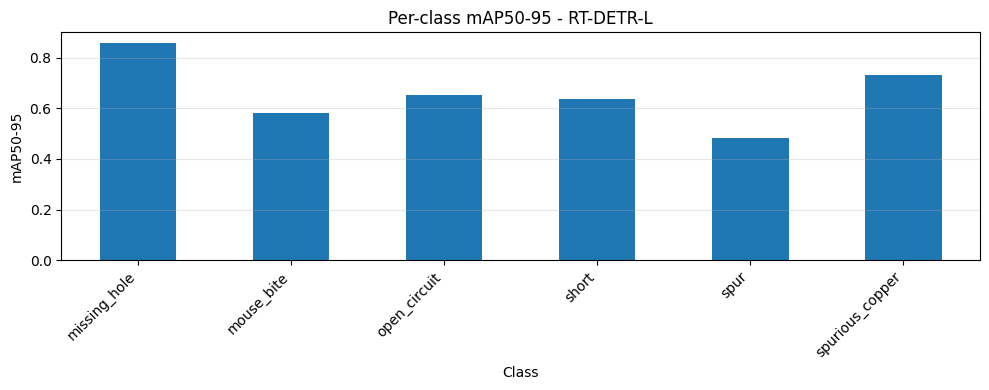

In [9]:
if len(per_class_df) > 0:
    ax = per_class_df.set_index("class_name")["mAP50_95_per_class"].plot(kind="bar", figsize=(10, 4))
    ax.set_title("Per-class mAP50-95 - RT-DETR-L")
    ax.set_xlabel("Class")
    ax.set_ylabel("mAP50-95")
    ax.grid(axis="y", alpha=0.3)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(REPORT_DIR / f"{TRAIN_NAME}_per_class_map.png", dpi=160)
    plt.show()

## 9. Export artifacts

In [10]:
ARTIFACT_DIR = ROOT / "rt_detr_artifacts"
EXPORT_DIR = ARTIFACT_DIR / TRAIN_NAME
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

for file_name in [
    "results.csv",
    "confusion_matrix.png",
    "confusion_matrix_normalized.png",
    "F1_curve.png",
    "P_curve.png",
    "R_curve.png",
    "PR_curve.png",
]:
    src = TRAIN_DIR / file_name
    if src.exists():
        shutil.copy2(src, EXPORT_DIR / file_name)

if eval_weight.exists():
    shutil.copy2(eval_weight, EXPORT_DIR / eval_weight.name)

for p in REPORT_DIR.glob(f"{TRAIN_NAME}*"):
    shutil.copy2(p, EXPORT_DIR / p.name)

ZIP_OUTPUT = ROOT / f"{TRAIN_NAME}_artifacts.zip"
if ZIP_OUTPUT.exists():
    ZIP_OUTPUT.unlink()

shutil.make_archive(
    base_name=str(ZIP_OUTPUT.with_suffix("")),
    format="zip",
    root_dir=str(ARTIFACT_DIR),
    base_dir=TRAIN_NAME,
)

print("Exported:", EXPORT_DIR)
print("Created zip:", ZIP_OUTPUT)
print("Size MB:", ZIP_OUTPUT.stat().st_size / (1024 * 1024))

Exported: /kaggle/working/rt_detr_artifacts/rt_detr_l_final_clean_6cls_e50
Created zip: /kaggle/working/rt_detr_l_final_clean_6cls_e50_artifacts.zip
Size MB: 58.4458646774292


## Files to download

Download:

- `/kaggle/working/rt_detr_l_final_clean_6cls_e50_artifacts.zip`
- `/kaggle/working/rt_detr_reports/rt_detr_l_final_clean_6cls_e50_summary_metrics.csv`
- `/kaggle/working/rt_detr_reports/rt_detr_l_final_clean_6cls_e50_per_class_map.csv`
- `/kaggle/working/rt_detr_reports/rt_detr_l_final_clean_6cls_e50_metrics.json`